In [1]:
from google.colab.patches import cv2_imshow
from google.colab import drive
import numpy as np
import cv2
import matplotlib.pyplot as plt
drive.mount('/content/gdrive')

Mounted at /content/gdrive


(360, 360, 3)


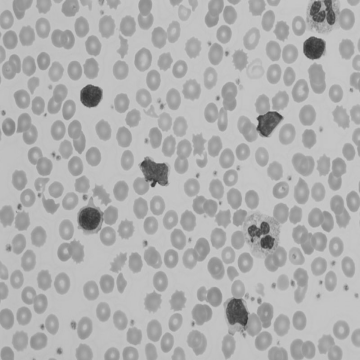

In [65]:
#img = cv2.imread('/content/gdrive/My Drive/IP/Images/lena256.jpg')
#img = cv2.imread('/content/gdrive/My Drive/IP/Images/rice.bmp')
img = cv2.imread('/content/gdrive/My Drive/IP/Images/cell.bmp')
#img = cv2.imread('/content/gdrive/My Drive/IP/Images/cell-bright.bmp')
#img = cv2.imread('/content/gdrive/My Drive/IP/Images/milkdrop.bmp')

print(img.shape)
gimg1 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#plt.imshow(gimg1, cmap='gray')
cv2_imshow(gimg1)

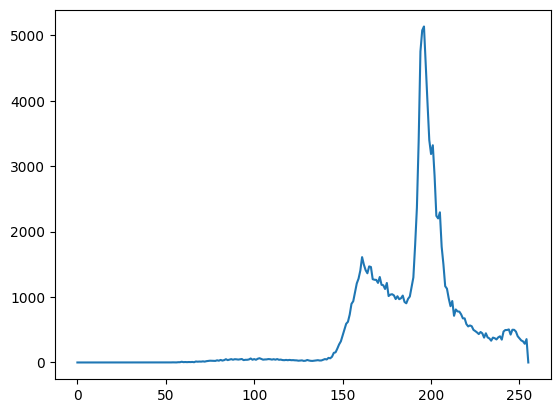

In [66]:
#hist = cv2.calcHist([gimg1],[0],None,[256],[0,255])
plt.plot(hist)

In [67]:
gBin = np.zeros((gimg1.shape[0], gimg1.shape[1]), dtype=np.ubyte)

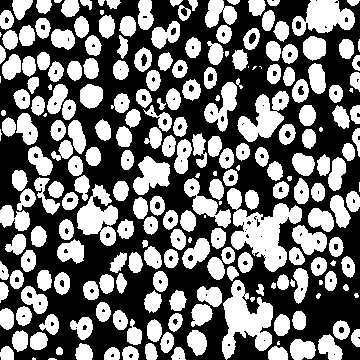

In [68]:
Threshold = 180
for h in range(gimg1.shape[0]):
  for w in range(gimg1.shape[1]):
    if gimg1[h,w] > Threshold:
      gBin[h,w] = 0
    else:
      gBin[h,w] = 255

cv2_imshow(gBin)

In [69]:
T1 = 150
T2 = 0
T0 = 1

In [70]:
def threshold_update(img, bimg):
  sum1 = 0
  count1 = 1
  sum2 = 0
  count2 = 1

  for h in range(img.shape[0]):
    for w in range(img.shape[1]):
      if(bimg[h, w] == 0):
        sum1 = np.int32(sum1 + img[h, w])
        count1 += 1
      else:
        sum2 = np.int32(sum2 + img[h, w])
        count2 += 1
  av1 = sum1/count1
  av2 = sum2/count2
  T = (av1 + av2)/2
  return T

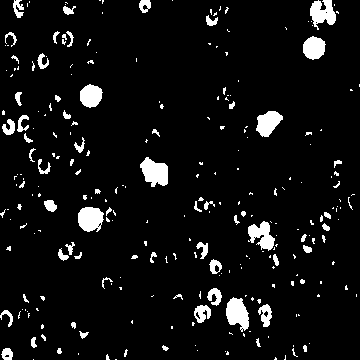

In [71]:
T = threshold_update(gimg1, gBin)
for h in range(gimg1.shape[0]):
  for w in range(gimg1.shape[1]):
    if(gimg1[h, w] > T1):
      gBin[h, w] = 0
    else:
      gBin[h, w] = 255

cv2_imshow(gBin)

In [74]:
while True:
  T2 = threshold_update(gimg1, gBin)

  if(np.abs(T1-T2) < T0):
   break
  else:
    T1 = T2
    for h in range(img.shape[0]):
      for w in range(img.shape[1]):
        if(img[h, w] > T1):
          gBin[h, w] = 255
        else:
          gBin[h, w] = 0

    print(T2)
    cv2_imshow(gBin)